In [1]:
import sys
import os
import pytest

from tqdm.notebook import tqdm, trange
import jax
jax.config.update("jax_enable_x64", True)

import jax.tree as jtu
import jax.numpy as np
import jax.random as jr
from jax import Array
from jax.flatten_util import ravel_pytree
import equinox as eqx
from zodiax.diffops import hessian
from zodiax.optimisation import eigen_projection

from optax import sgd, adam
import optimistix as optx

import amigo as amg
import dorito as drt
from dorito.model_fits import PointResolvedFit as prf
from dorito.model_fits import ResolvedOIFit
from dorito.model_fits import _OIFit
from dorito.models import ResolvedAmigoModel
from dorito.models import ResolvedDiscoModel
from dorito.bases import ImageBasis
from dorito.models import BaseModeller
from dorito.stats import disco_regularised_loss_fn


from kneed import KneeLocator

import dLux.utils as dlu

# matplotlib configs
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyBboxPatch
import ehtplot
import scienceplots
import cmasher as cmr

plt.style.use(["science", "bright", "no-latex"])
new_rcParams = {
    "image.cmap": "inferno",
    "font.family": "serif",
    "image.origin": "lower",
    "figure.dpi": 300,
    "font.size": 8,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

from frito.autoencoder.ae_utils import load_classes_from_file as lcf, run_svd
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
)
from frito.jax_gaussian import gaussian_filter
from frito.plot import main_mosaic
from frito import (
    TransformedResolvedDiscoModel as TRDM,
    AutoencoderBasis,
    TransformedResolvedOIFit as TROIF,
    PointResolvedOIFit as PROIF,
    PointResolvedDiscoModel as PRDM,
    disco_regularised_loss_forecast_fn as drl_forecast_fn,
    oi_log_likelihood_forecast as oi_ll_forecast,
    latent_gaussian_prior as lgp,
)

In [2]:
master_key = jr.key(42)
main_data_path = "_data"
autoencoder_data_path = os.path.join(main_data_path, "autoencoder")
main_trained_model_path = os.path.join(autoencoder_data_path, "trained_models")
main_svd_path = os.path.join(autoencoder_data_path, "svd")
training_data_path = os.path.join(autoencoder_data_path, "training_data")
emnist_path = os.path.join(training_data_path, "emnist.npz")
mnist_path = os.path.join(training_data_path, "mnist.npz")
ppd_51_path = os.path.join(training_data_path, "fake_intensity_PPDs_51x51.npz")

main_out_path = "_output"
main_model_struct_path = "src/frito/autoencoder/model_structures"

ppd_51x51_data = np.load(ppd_51_path)
test_51x51_data = ppd_51x51_data["x_test"]

disco_HD100546_path = os.path.join(
    main_data_path, "jwst", "HD100546", "disco", "cal_vis_HD-100546 (1).npy"
)
disco_HD135344B_path = os.path.join(
    main_data_path, "jwst", "HD135344B", "disco", "cal_vis_HD135344B.npy"
)
disco_PDS70_path = os.path.join(
    main_data_path, "jwst", "PDS70", "disco", "bgmask_cal_vis_pds70.npy"
)

In [3]:
disco_PDS70 = np.load(disco_PDS70_path, allow_pickle=True).item()
disco_HD100546 = np.load(disco_HD100546_path, allow_pickle=True).item()
disco_HD135344B = np.load(disco_HD135344B_path, allow_pickle=True).item()

In [4]:
model_key, master_key = jr.split(master_key, 2)
model_type = "PPD"
i = 16
model_names = [
    "0_0",
    "0_2",
    "1_0",
    "1_2",
    "2_0",
    "2_1",
    "2_2",
    "3_0",
    "3_1",
    "3_2",
    "4_0",
    "4_1",
    "4_2",
    "7_0",
    "7_1",
    "7_2",
    "7_4",
    "7_5",
    "8_0",
    "8_2",
    "8_3",
    "8_4",
    "8_5",
    "8_6",
]
model_name = model_names[i]
model_struct_path = os.path.join(
    main_model_struct_path, f"model_{model_name}.py"
)
trained_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_best.eqx"
)
autoencoder_classes = lcf(model_struct_path)
autoencoder = autoencoder_classes["autoencoder"](key=model_key)
base_autoencoder = eqx.tree_deserialise_leaves(trained_model_path, autoencoder)

print(f"Model: {model_name}")
print(f"Model Struct: {model_struct_path}")
print(f"Trained Model Path: {trained_model_path}")
print(f"Autoencoder Classes: {autoencoder_classes}")

Model: 7_4
Model Struct: src/frito/autoencoder/model_structures/model_7_4.py
Trained Model Path: _data/autoencoder/trained_models/PPD/7_4_best.eqx
Autoencoder Classes: {'autoencoder': <class 'model_7_4.autoencoder'>, 'decoder': <class 'model_7_4.decoder'>, 'encoder': <class 'model_7_4.encoder'>}


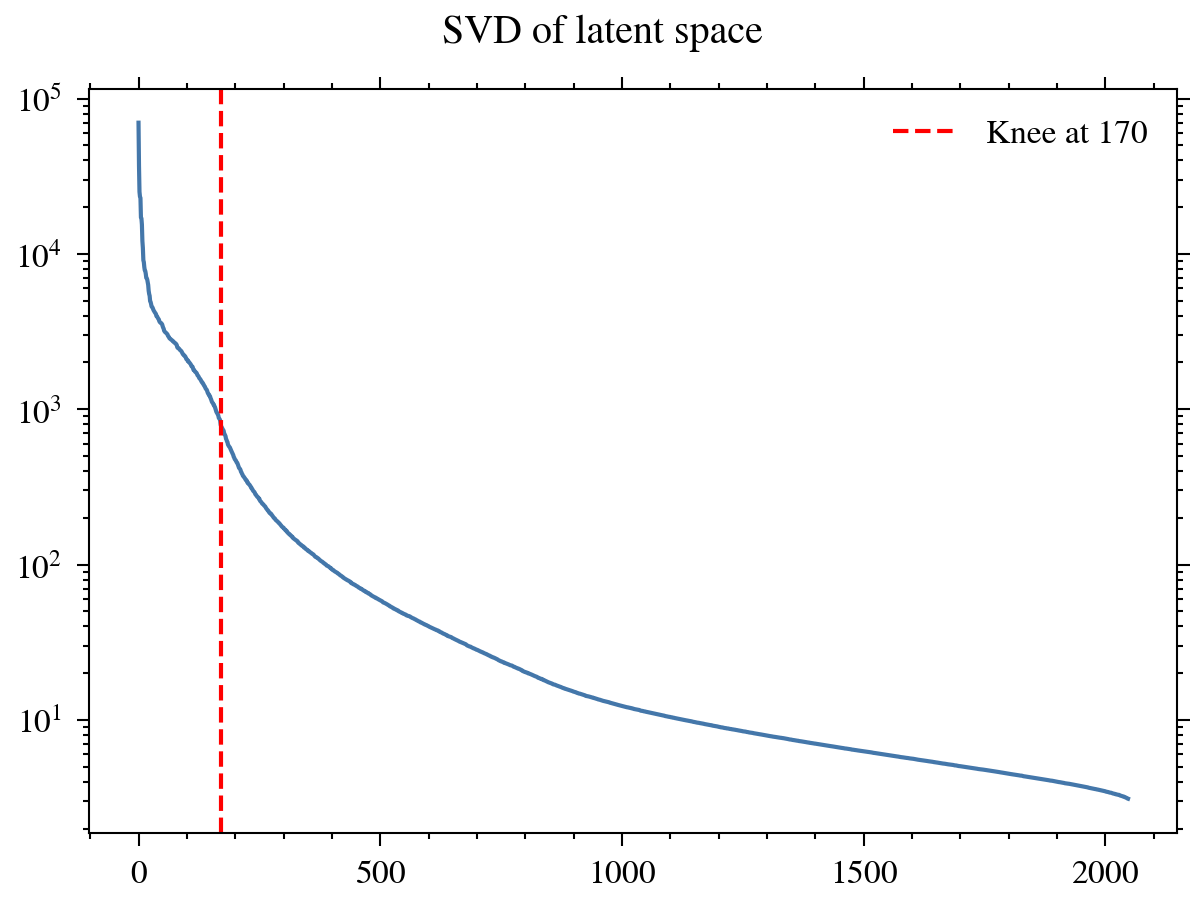

SVD Path: _data/autoencoder/svd/PPD_model_7_4_svd.npz
Knee at 170


In [5]:
svd_path = os.path.join(
    main_svd_path, f"{model_type}_model_{model_name}_svd.npz"
)
svd = np.load(svd_path)

k1 = KneeLocator(
    np.arange(len(svd["s"])),
    svd["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of latent space")
ax.plot(svd["s"], marker=",")
ax.axvline(k1.knee, color="r", linestyle="--", label=f"Knee at {k1.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd_path}")
print(f"Knee at {k1.knee}")

In [6]:
tmp_keys = jr.split(master_key, 3)
suture_keys = tmp_keys[:2]
master_key = tmp_keys[2]

new_encode_in = base_autoencoder.modules[0].layers[-1].in_features
new_encode_out = int(k1.knee)
new_encode_latent_weights = (
    base_autoencoder.modules[0].layers[-1].weight[:new_encode_out, :]
)
new_encode_latent_biases = (
    base_autoencoder.modules[0].layers[-1].bias[:new_encode_out]
)
new_encode_linear = eqx.nn.Linear(
    in_features=new_encode_in, out_features=new_encode_out, key=suture_keys[0]
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.weight, new_encode_linear, new_encode_latent_weights
)
trained_new_encode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_encode_linear, new_encode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers[-1],
    base_autoencoder,
    trained_new_encode_linear,
)


def embed(X, knee, m, s, v):
    return (X - m[:knee]) @ v[:knee, :knee].T / np.sqrt(s[:knee] ** 2 / 99999)


embed_layer = eqx.nn.Lambda(
    lambda z: embed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[0].layers,
    sutured_ae_struct,
    sutured_ae_struct.modules[0].layers + [embed_layer],
)


def unembed(embedded, knee, m, s, v):
    return ((embedded) * np.sqrt(s[:knee] ** 2 / 99999)) @ v[:knee, :knee] + m[
        :knee
    ]


unembed_layer = eqx.nn.Lambda(
    lambda z: unembed(z, int(k1.knee), svd["mean"], svd["s"], svd["v"])
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae_struct,
    [unembed_layer] + sutured_ae_struct.modules[1].layers,
)

new_decode_out = sutured_ae_struct.modules[1].layers[2].out_features
new_decode_in = int(k1.knee)
new_decode_latent_weights = (
    sutured_ae_struct.modules[1].layers[2].weight[:, :new_decode_in]
)
new_decode_latent_biases = sutured_ae_struct.modules[1].layers[2].bias
new_decode_linear = eqx.nn.Linear(
    in_features=new_decode_in, out_features=new_decode_out, key=suture_keys[1]
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.weight, new_decode_linear, new_decode_latent_weights
)
trained_new_decode_linear = eqx.tree_at(
    lambda l: l.bias, trained_new_decode_linear, new_decode_latent_biases
)
sutured_ae_struct = eqx.tree_at(
    lambda m: m.modules[1].layers[2],
    sutured_ae_struct,
    trained_new_decode_linear,
)

sutured_model_path = os.path.join(
    main_trained_model_path, model_type, f"{model_name}_Rbest.eqx"
)
sutured_ae = eqx.tree_deserialise_leaves(sutured_model_path, sutured_ae_struct)
print(f"Suture Model Path: {sutured_model_path}")


def sum2unity(X):
    pix_sum = np.sum(X, axis=(1, 2), keepdims=True)
    norm_pix = X / pix_sum
    return norm_pix


sum2unity_layer = eqx.nn.Lambda(lambda z: sum2unity(z))
norm_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    sutured_ae,
    sutured_ae.modules[1].layers + [sum2unity_layer],
)

# encoder, decoder = sutured_ae.modules
encoder, decoder = norm_sutured_ae.modules

Suture Model Path: _data/autoencoder/trained_models/PPD/7_4_Rbest.eqx


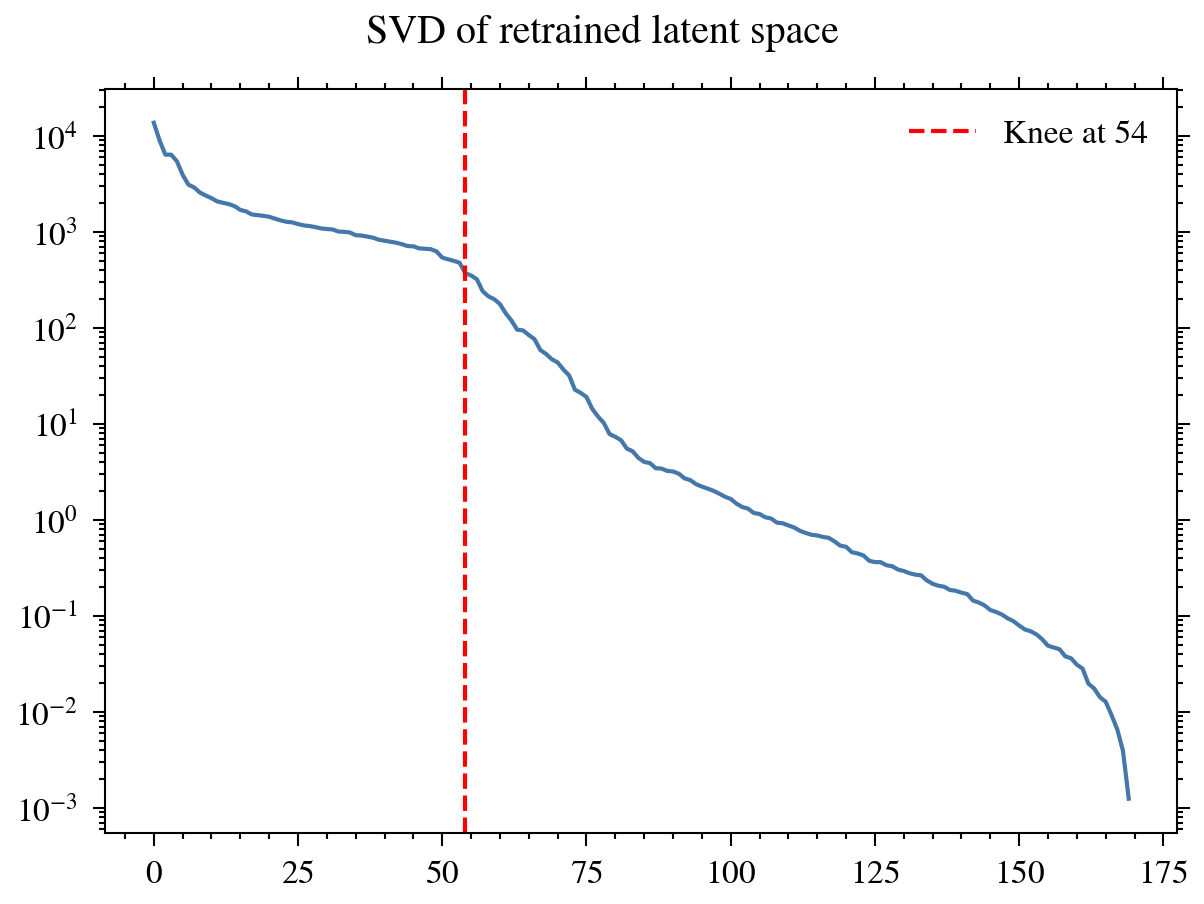

SVD Path: _data/autoencoder/svd/PPD_retrain_model_7_4_svd.npz
Knee at 54


In [7]:
svd2_path = os.path.join(
    main_svd_path, f"{model_type}_retrain_model_{model_name}_svd.npz"
)
svd2 = np.load(svd2_path)
k2 = KneeLocator(
    np.arange(len(svd2["s"])),
    svd2["s"],
    curve="convex",
    direction="decreasing",
    online=True,
)

fig, ax = plt.subplots(figsize=(4, 3), layout="constrained")
fig.suptitle("SVD of retrained latent space")
ax.plot(svd2["s"], marker=",")
ax.axvline(k2.knee, color="r", linestyle="--", label=f"Knee at {k2.knee}")
ax.legend()
ax.set_yscale("log")
plt.show()

print(f"SVD Path: {svd2_path}")
print(f"Knee at {k2.knee}")

In [8]:
def embed2(X, m, s, v):
    return (X - m) @ v.T / np.sqrt(s**2 / 99999)


embed_layer2 = eqx.nn.Lambda(
    lambda z: embed2(z, svd2["mean"], svd2["s"], svd2["v"])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[0].layers,
    norm_sutured_ae,
    norm_sutured_ae.modules[0].layers + [embed_layer2],
)


def unembed2(embedded, m, s, v):
    return ((embedded) * np.sqrt(s**2 / 99999)) @ v + m


unembed_layer2 = eqx.nn.Lambda(
    lambda z: unembed2(z, svd2["mean"], svd2["s"], svd2["v"])
)
norm2_sutured_ae = eqx.tree_at(
    lambda m: m.modules[1].layers,
    norm2_sutured_ae,
    [unembed_layer2] + norm2_sutured_ae.modules[1].layers,  # [1:],
)
encoder, decoder = norm2_sutured_ae.modules

In [9]:
disco_HD100546['F480M'].keys()

dict_keys(['u', 'v', 'vis_mat', 'phi_mat', 'K_vis_mat', 'K_phi_mat', 'parang', 'wavel', 'O_vis', 'O_phi', 'O_vis_cov', 'O_phi_cov', 'O_vis_mat', 'O_phi_mat', 'O_vis_eigv', 'O_phi_eigv', 'disco_vis_mat', 'disco_phi_mat', 'K_vis', 'K_vis_cov', 'K_phi', 'K_phi_cov', 'vis', 'vis_cov', 'phi', 'phi_cov'])

Text(0.5, 1.0, 'Initial Distribution | Sum: 0.9999999999999998')

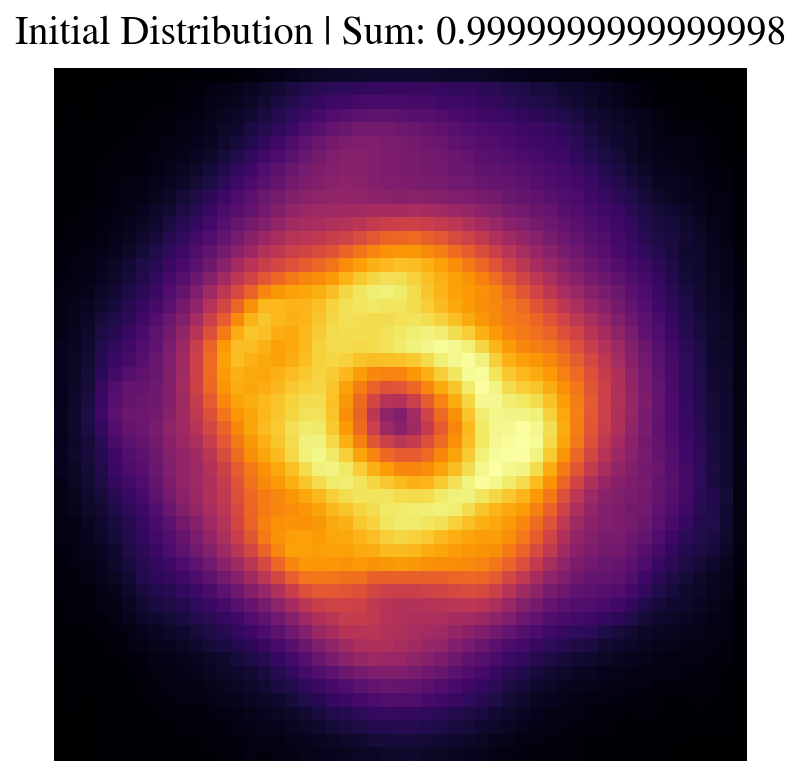

In [10]:
init_latent = np.zeros((170,))
init_dist = decoder(init_latent)
init_dist = init_dist[0]
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(init_dist)
ax.set_axis_off()
ax.set_title(f"Initial Distribution | Sum: {np.sum(init_dist)}")

In [11]:
# filter = "F380M"
# n_epochs = 1000
# ld_lr = 1e-5
# c_lr = 6e-10
# filter = "F430M"
# n_epochs = 1000
# ld_lr = 5e-6
# c_lr = 5e-10
filter = "F480M"
n_epochs = 5000
ld_lr = 5e-5
c_lr = 1e-9
prior = 1


In [12]:
rand_key, master_key = jr.split(master_key, 2)
z0 = jr.normal(rand_key, (170,))
init_dist_i = decoder(z0)[0]

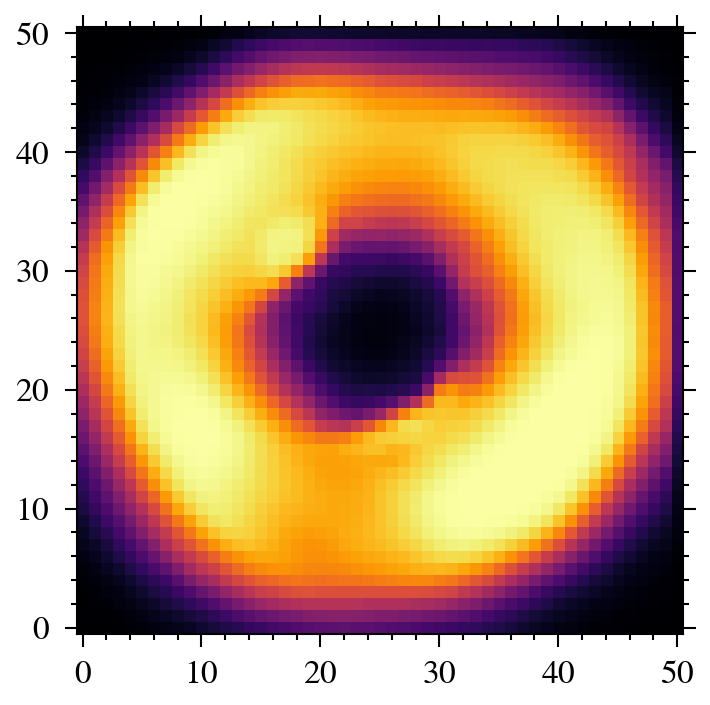

In [13]:
plt.imshow(init_dist_i/init_dist_i.max())

In [14]:
basis = AutoencoderBasis(norm2_sutured_ae)
# ois = [
#     PROIF(
#         oi_data,
#         key,
#         filter=key,
#     )
#     for key, oi_data in disco_PDS70.items()
# ]
oi_data = disco_HD100546[filter]
ois = [PROIF(oi_data, filter, filter=filter)]

baselines = np.sqrt(ois[0].u**2+ois[0].v**2)
base_flat = np.tile(baselines, ois[0].vis_mat.shape[0])
threshold = 0.005
optics_diameter = base_flat[ois[0].vis_mat.flatten() > threshold].max()
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

model = PRDM(
    ois=ois,
    distribution=init_dist, #2*np.ones((51,51)),#init_dist_i/init_dist_i.max(),
    basis=basis,
    contrast=0.45,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=2.0,
)


def norm_fn(model_params, args):
    params = model_params.params

    # NOTE: This normalisation won't work for an arbitrary basis!
    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            params["log_dist"][k] = log_dist
    return model_params.set("params", params), args


def grad_fn(model, grads, args):
    return grads, args


config = {
    # "log_dist": adam(1e-3, 0),
    "log_dist": adam(ld_lr, 0),  # adam(7.5e-4, 0),#adam(1e-3, 0),
    "contrast": sgd(c_lr, 0),
    # "contrast": sgd(2e-8, 100),
    # "log_dist": adam(5e-3, 0),
}


args = {
    "reg_dict": {"latent_gaussian_prior": (prior, lgp)},
    "basis": basis,
}
trainer = amg.fitting.Trainer(
    loss_fn=disco_regularised_loss_fn,
    norm_fn=norm_fn,
    grad_fn=grad_fn,
    cache="_data/amigo/fisher",
)
trainer = trainer.update_fishers(
    model=model,
    exposures=ois,
    parameters=[],
)


result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epochs,
    batches=ois,
    args=args,
)
frito_model = result.model


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 2,230,995.95
Estimated run time: 0:02:44
Full Time: 0:03:13
Final Loss: 290,168.51


In [15]:
def run_filter_bfgs(
    model, oi, filter_name, args, max_steps=500, rtol=1e-8, atol=1e-8
):
    x_map = {
        "log_dist": model.params["log_dist"][filter_name],
        "contrast": model.params["contrast"][filter_name],
    }

    def neg_log_post(x):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = disco_regularised_loss_fn(m, oi, args)
        return loss

    forecast = np.array(oi(model))

    def neg_log_post_forecast(x, forecast):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = drl_forecast_fn(m, oi, forecast, args)
        return loss

    # DIAGNOSTICS
    f0 = float(neg_log_post(x_map))
    g0 = jax.grad(neg_log_post)(x_map)
    g0_flat, _ = ravel_pytree(g0)
    print(
        f"[{filter_name}] loss={f0:.3e}, "
        f"‖grad‖_inf={float(np.max(np.abs(g0_flat))):.3e}"
    )

    # HESSIAN

    print(f"[{filter_name}] computing Hessian...")
    H, _ = hessian(
        lambda x: neg_log_post_forecast(x, forecast),
        x_map,
        nbatches=1,
        jit=True,
    )

    def safe_fisher(H, floor_rel=1e-8):
        """Symmetrise H and reconstruct it with eigenvalues floored to be
        strictly positive. The result is PSD and safe to pass to eigen_projection."""
        H_sym = 0.5 * (H + H.T)
        vals, vecs = np.linalg.eigh(H_sym)
        floor = floor_rel * np.max(
            np.abs(vals)
        )  # use abs in case max is negative
        vals_clipped = np.clip(vals, floor, None)
        return (vecs * vals_clipped) @ vecs.T

    H_safe = safe_fisher(H)
    P = eigen_projection(fmat=H_safe)

    X0, unravel = ravel_pytree(x_map)
    n = X0.size

    def project_fn(u):
        return X0 + P @ u

    # Projected loss for BFGS
    @jax.jit
    def projected_loss(u, _args):
        return neg_log_post(unravel(project_fn(u)))

    # running bfgs
    print(f"[{filter_name}] running BFGS in latent space...")
    solver = optx.BestSoFarMinimiser(optx.BFGS(rtol=rtol, atol=atol))

    u0 = np.zeros(n)

    sol = optx.minimise(
        projected_loss,
        solver,
        u0,
        args=None,
        max_steps=max_steps,
        throw=False,
    )

    # project back into param space
    u_opt = sol.value
    x_opt = unravel(project_fn(u_opt))

    # ---- Diagnostics after ----
    f1 = float(neg_log_post(x_opt))
    g1 = jax.grad(neg_log_post)(x_opt)
    g1_flat, _ = ravel_pytree(g1)
    print(
        f"[{filter_name}] after:  loss={f1:.3e}, "
        f"‖grad‖_inf={float(np.max(np.abs(g1_flat))):.3e}, "
        f"steps={int(sol.stats['num_steps'])}, "
        f"result={optx.RESULTS[sol.result]}"
    )

    # Write back into model
    new_log_dist = dict(model.params["log_dist"])
    new_log_dist[filter_name] = x_opt["log_dist"]
    new_contrast = dict(model.params["contrast"])
    new_contrast[filter_name] = x_opt["contrast"]
    new_params = dict(model.params)
    new_params["log_dist"] = new_log_dist
    new_params["contrast"] = new_contrast
    new_model = eqx.tree_at(lambda mm: mm.params, model, new_params)

    return {
        "model": new_model,
        "x_opt": x_opt,
        "u_opt": u_opt,
        "loss_before": f0,
        "loss_after": f1,
        "grad_inf_before": float(np.max(np.abs(g0_flat))),
        "grad_inf_after": float(np.max(np.abs(g1_flat))),
        "H_before": H,
        "P": P,
        "X0": X0,
        "sol": sol,
    }


bfgs_results = {}
for oi in ois:
    fname = oi.filter
    bfgs_result = run_filter_bfgs(
        frito_model, oi, fname, args, max_steps=2500, rtol=1e-8, atol=1e-8
    )
    bfgs_results[fname] = bfgs_result
bfgs_model = bfgs_results[filter]["model"]

[F480M] loss=2.901e+05, ‖grad‖_inf=6.406e+05
[F480M] computing Hessian...
[F480M] running BFGS in latent space...
[F480M] after:  loss=1.420e+05, ‖grad‖_inf=3.188e+01, steps=907, result=


In [16]:
dlu.rad2arcsec(ois[0].wavel / optics_diameter)

Array(0.16451097, dtype=float64)

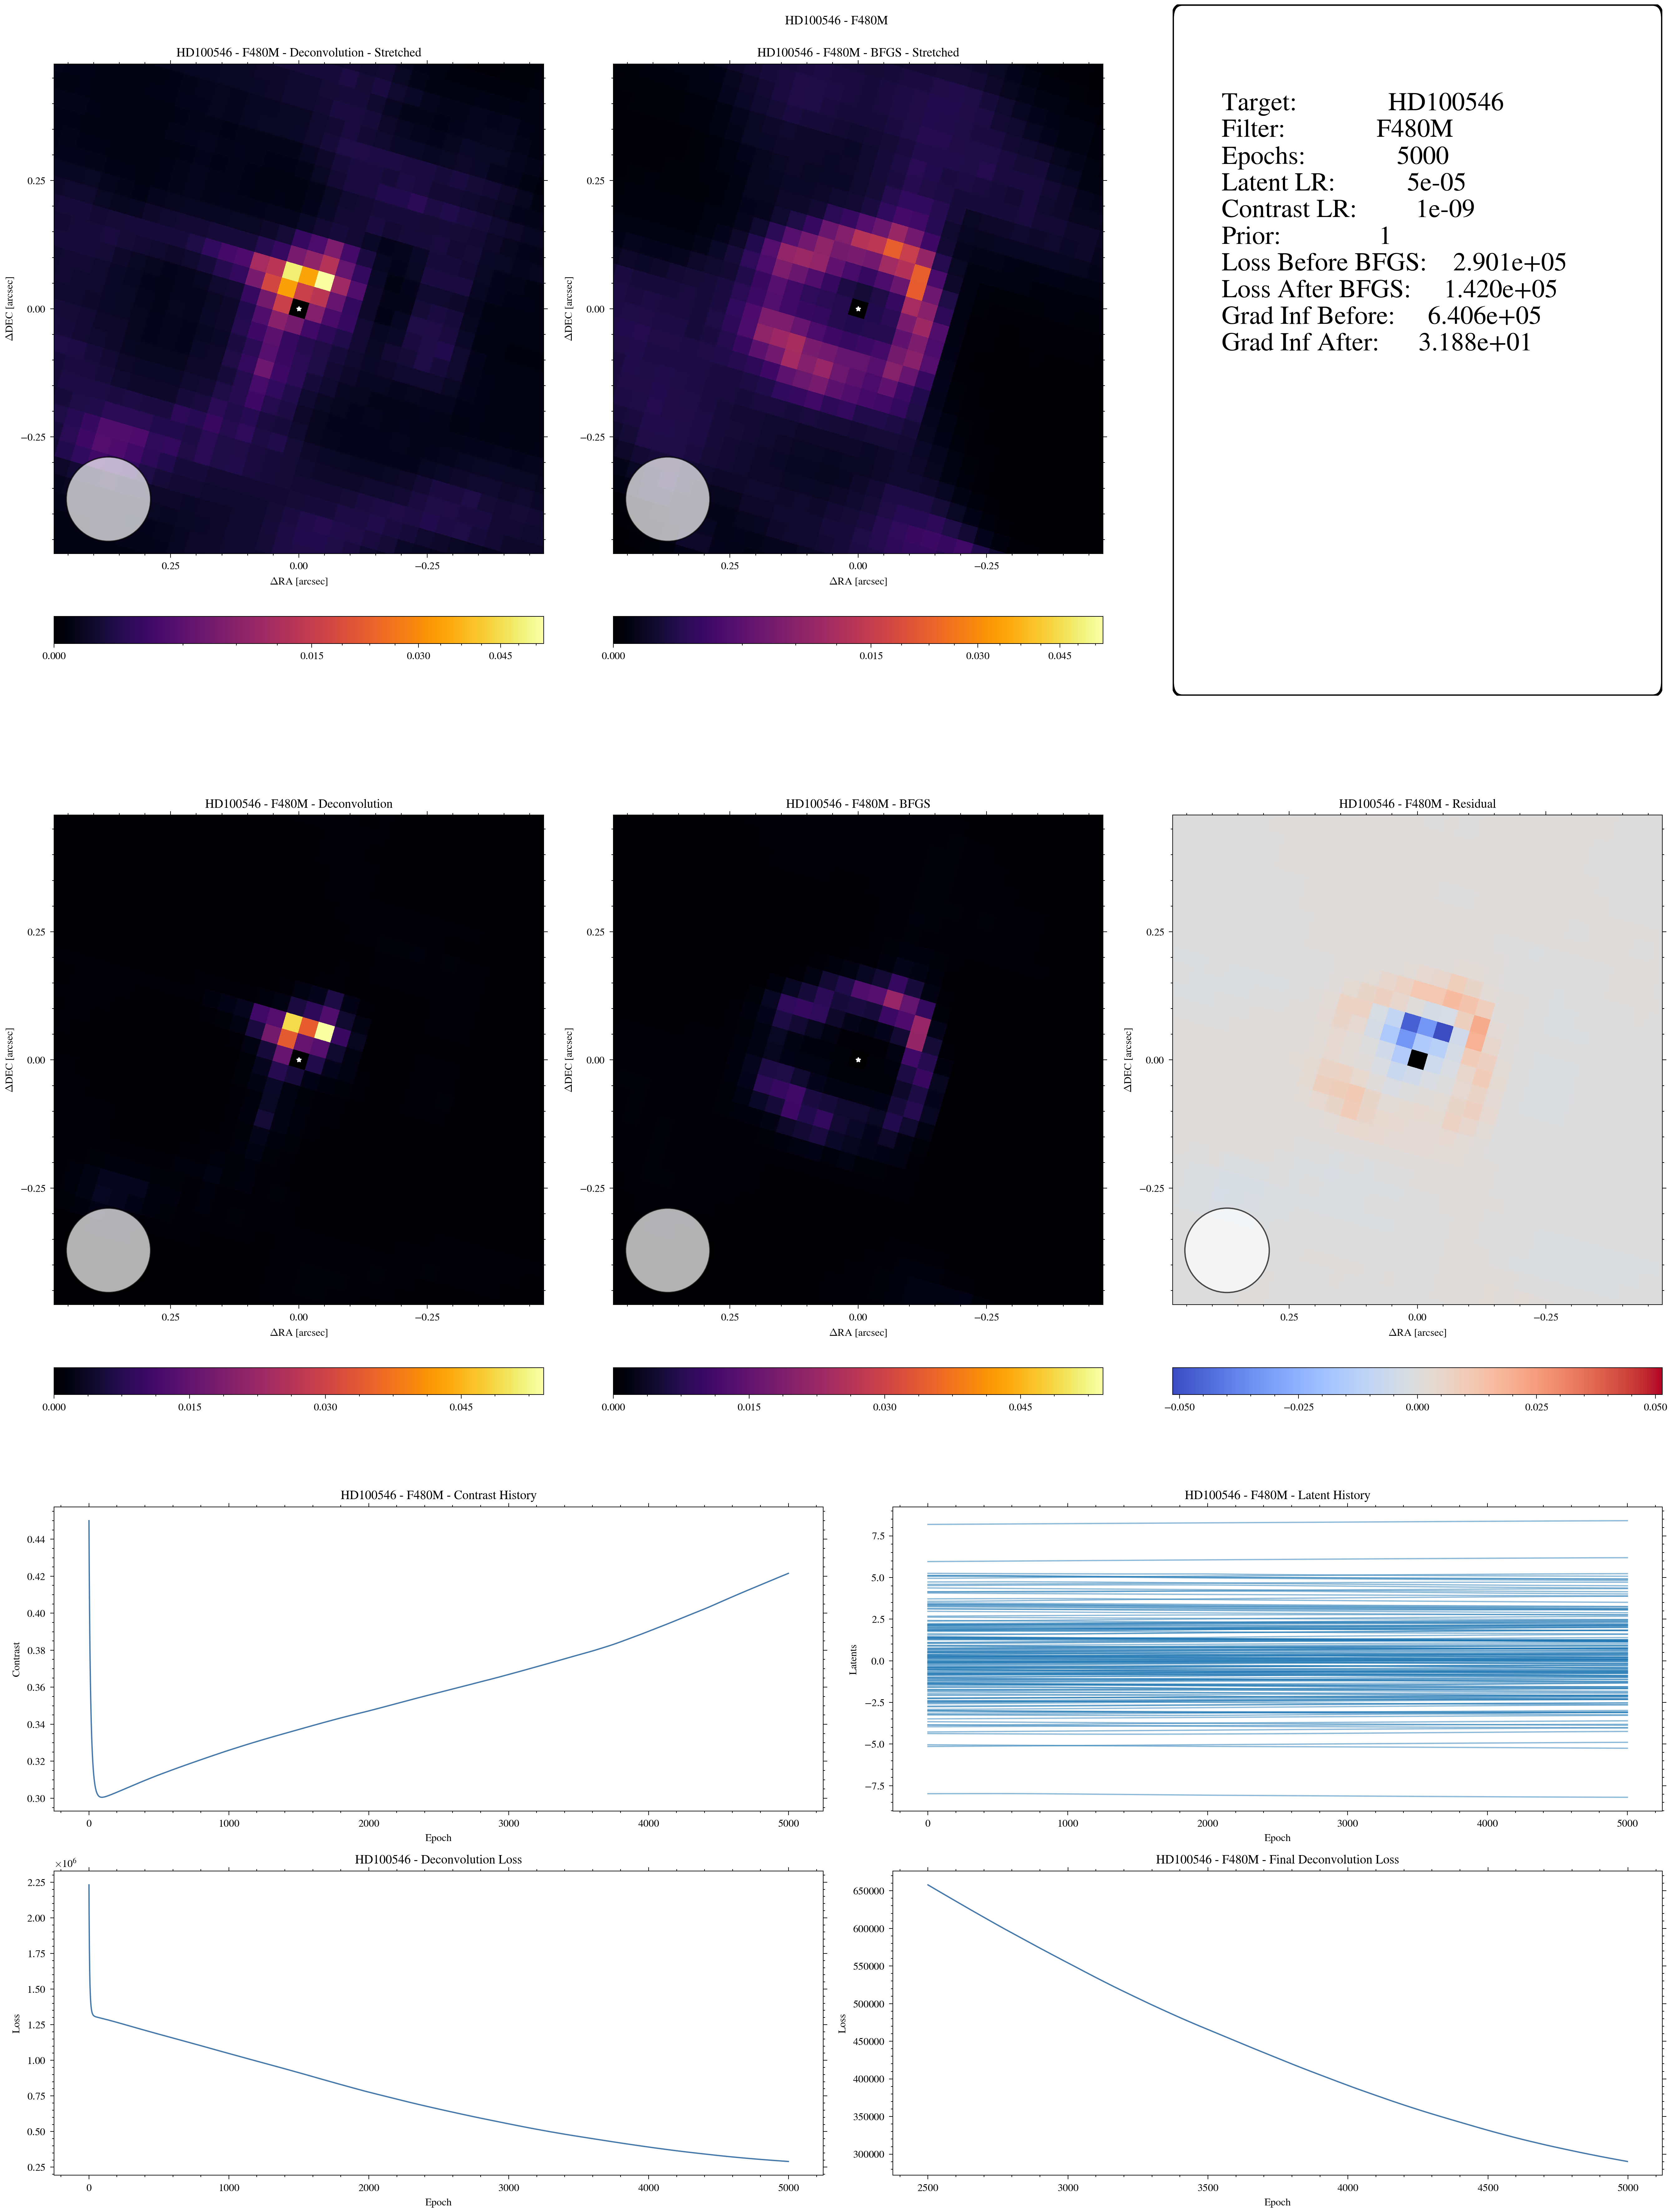

In [17]:
mosaic = main_mosaic(
    "HD100546",
    filter,
    ois,
    optics_diameter,
    frito_model,
    deconvolution_result=result,
    bfgs_model=bfgs_model,
    bfgs_result=bfgs_results[filter],
    epochs=n_epochs,
    log_dist_lr=ld_lr,
    contrast_lr=c_lr,
    prior=prior,
    scale=1.75,
    pixel_scale = dlu.rad2arcsec(frito_model.pscale_in),
    ticks = [-.5, -.25, 0, .25, 5]
)

In [18]:
def disco_correlation_plot(
    ois,
    model,
    filter: str,
    title: str | None = None,
    figsize=(12, 5),
    square_axes=True,
    n_bins: int | None = None,
    save: None | str = None,
):
    """
    Create 1:1 correlation plots of model vs data for disco amplitude and phase.
 
    Parameters
    ----------
    ois : list
        List of observation instances. Each must expose `.filter`, `.vis`,
        `.d_vis`, `.phi`, `.d_phi`, and be callable as `oi(model)` returning
        the concatenated [amplitude, phase] model prediction.
    model : Model
        The model to evaluate (passed to each `oi`).
    filter : str
        Filter name to match observations against `oi.filter`.
    title : str, optional
        Super title for the figure.
    figsize : tuple, optional
        Figure size.
    square_axes : bool, optional
        If True, enforce square aspect ratio for both subplots.
    n_bins : int, optional
        Number of bins for binning the data. If None, no binning is applied.
    save : None or str, optional
        If provided, save figure to this path.
    """
 
    # Pull data straight from the observation list
    vis_model_all, vis_data_all, vis_err_all = [], [], []
    phi_model_all, phi_data_all, phi_err_all = [], [], []
 
    for oi in ois:
        if oi.filter != filter:
            continue
        disco_amp_model, disco_phase_model = np.split(oi(model), 2)
        vis_model_all.append(disco_amp_model)
        vis_data_all.append(oi.vis)
        vis_err_all.append(oi.d_vis)
        phi_model_all.append(disco_phase_model)
        phi_data_all.append(oi.phi)
        phi_err_all.append(oi.d_phi)
 
    if not vis_model_all:
        raise ValueError(f"No observations found matching filter={filter!r}.")
 
    vis_model = np.concatenate(vis_model_all)
    vis_data = np.concatenate(vis_data_all)
    vis_err = np.concatenate(vis_err_all)
    phi_model = np.concatenate(phi_model_all)
    phi_data = np.concatenate(phi_data_all)
    phi_err = np.concatenate(phi_err_all)
 
    fig, axes = plt.subplots(1, 2, figsize=figsize)
 
    if title is not None:
        fig.suptitle(title)
 
    # Bin if requested
    if n_bins is not None:
        # Bin the visibilities
        bin_inds = np.array_split(np.argsort(vis_model), n_bins)
        vis_model_binned, vis_std = bin_data(vis_model, vis_model, bin_inds)
        vis_data_binned, vis_err_binned = bin_data(vis_data, vis_err, bin_inds)
 
        # Std dev in each bin for model
        vis_model_std = np.array([np.std(vis_model[inds]) for inds in bin_inds])
 
        # Bin the phases
        bin_inds = np.array_split(np.argsort(phi_model), n_bins)
        phi_model_binned, phi_std = bin_data(phi_model, phi_model, bin_inds)
        phi_data_binned, phi_err_binned = bin_data(phi_data, phi_err, bin_inds)
 
        phi_model_std = np.array([np.std(phi_model[inds]) for inds in bin_inds])
 
        vis_model = vis_model_binned
        vis_data = vis_data_binned
        vis_err = vis_err_binned
        phi_model = phi_model_binned
        phi_data = phi_data_binned
        phi_err = phi_err_binned
 
        plot_vis_err = vis_model_std
        plot_phi_err = phi_model_std
    else:
        plot_vis_err = vis_err
        plot_phi_err = phi_err
 
    # Axis limits with padding
    vis_pad = float(np.median(vis_err))
    phi_pad = float(np.median(phi_err))
 
    vis_min = min(vis_model.min(), vis_data.min()) - vis_pad
    vis_max = max(vis_model.max(), vis_data.max()) + vis_pad
    phi_min = min(phi_model.min(), phi_data.min()) - phi_pad
    phi_max = max(phi_model.max(), phi_data.max()) + phi_pad
 
    vis_line = np.linspace(vis_min, vis_max, 200)
    phi_line = np.linspace(phi_min, phi_max, 200)
 
    # Amplitude correlation
    axes[0].errorbar(
        vis_model,
        vis_data,
        xerr=plot_vis_err if n_bins else None,
        yerr=vis_err,
        fmt="o",
        markersize=4,
        alpha=0.25,
        elinewidth=1.0,
        capsize=2,
        color="midnightblue",
    )
 
    # Phase correlation
    axes[1].errorbar(
        phi_model,
        phi_data,
        xerr=plot_phi_err if n_bins else None,
        yerr=phi_err,
        fmt="o",
        markersize=4,
        alpha=0.25,
        elinewidth=1.0,
        capsize=2,
        color="midnightblue",
    )
 
    # 1:1 reference lines on top
    axes[0].plot(vis_line, vis_line, "r--", lw=1, label="y=x", zorder=10)
    axes[0].set_xlim(vis_min, vis_max)
    axes[0].set_ylim(vis_min, vis_max)
    axes[0].set_xlabel('Reconstructed Disco Amplitude')
    axes[0].set_ylabel('Calibrated Disco Amplitude')
    axes[0].set_title(f'{filter} - Amplitude Correlations')
    axes[0].legend(loc="best")
    if square_axes:
        axes[0].set_box_aspect(1)
 
    axes[1].plot(phi_line, phi_line, "r--", lw=1, label="y=x", zorder=10)
    axes[1].set_xlim(phi_min, phi_max)
    axes[1].set_ylim(phi_min, phi_max)
    axes[1].set_xlabel('Reconstructed Disco Phase')
    axes[1].set_ylabel('Calibrated Disco Phase')
    axes[1].set_title(f'{filter} - Phase Correlations')
    axes[1].legend(loc="best")
    if square_axes:
        axes[1].set_box_aspect(1)
 
    plt.tight_layout()
 
    if save is not None:
        fig.savefig(save, dpi=300, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()
 
    return fig, axes

In [19]:
from amigo.stats import bin_data

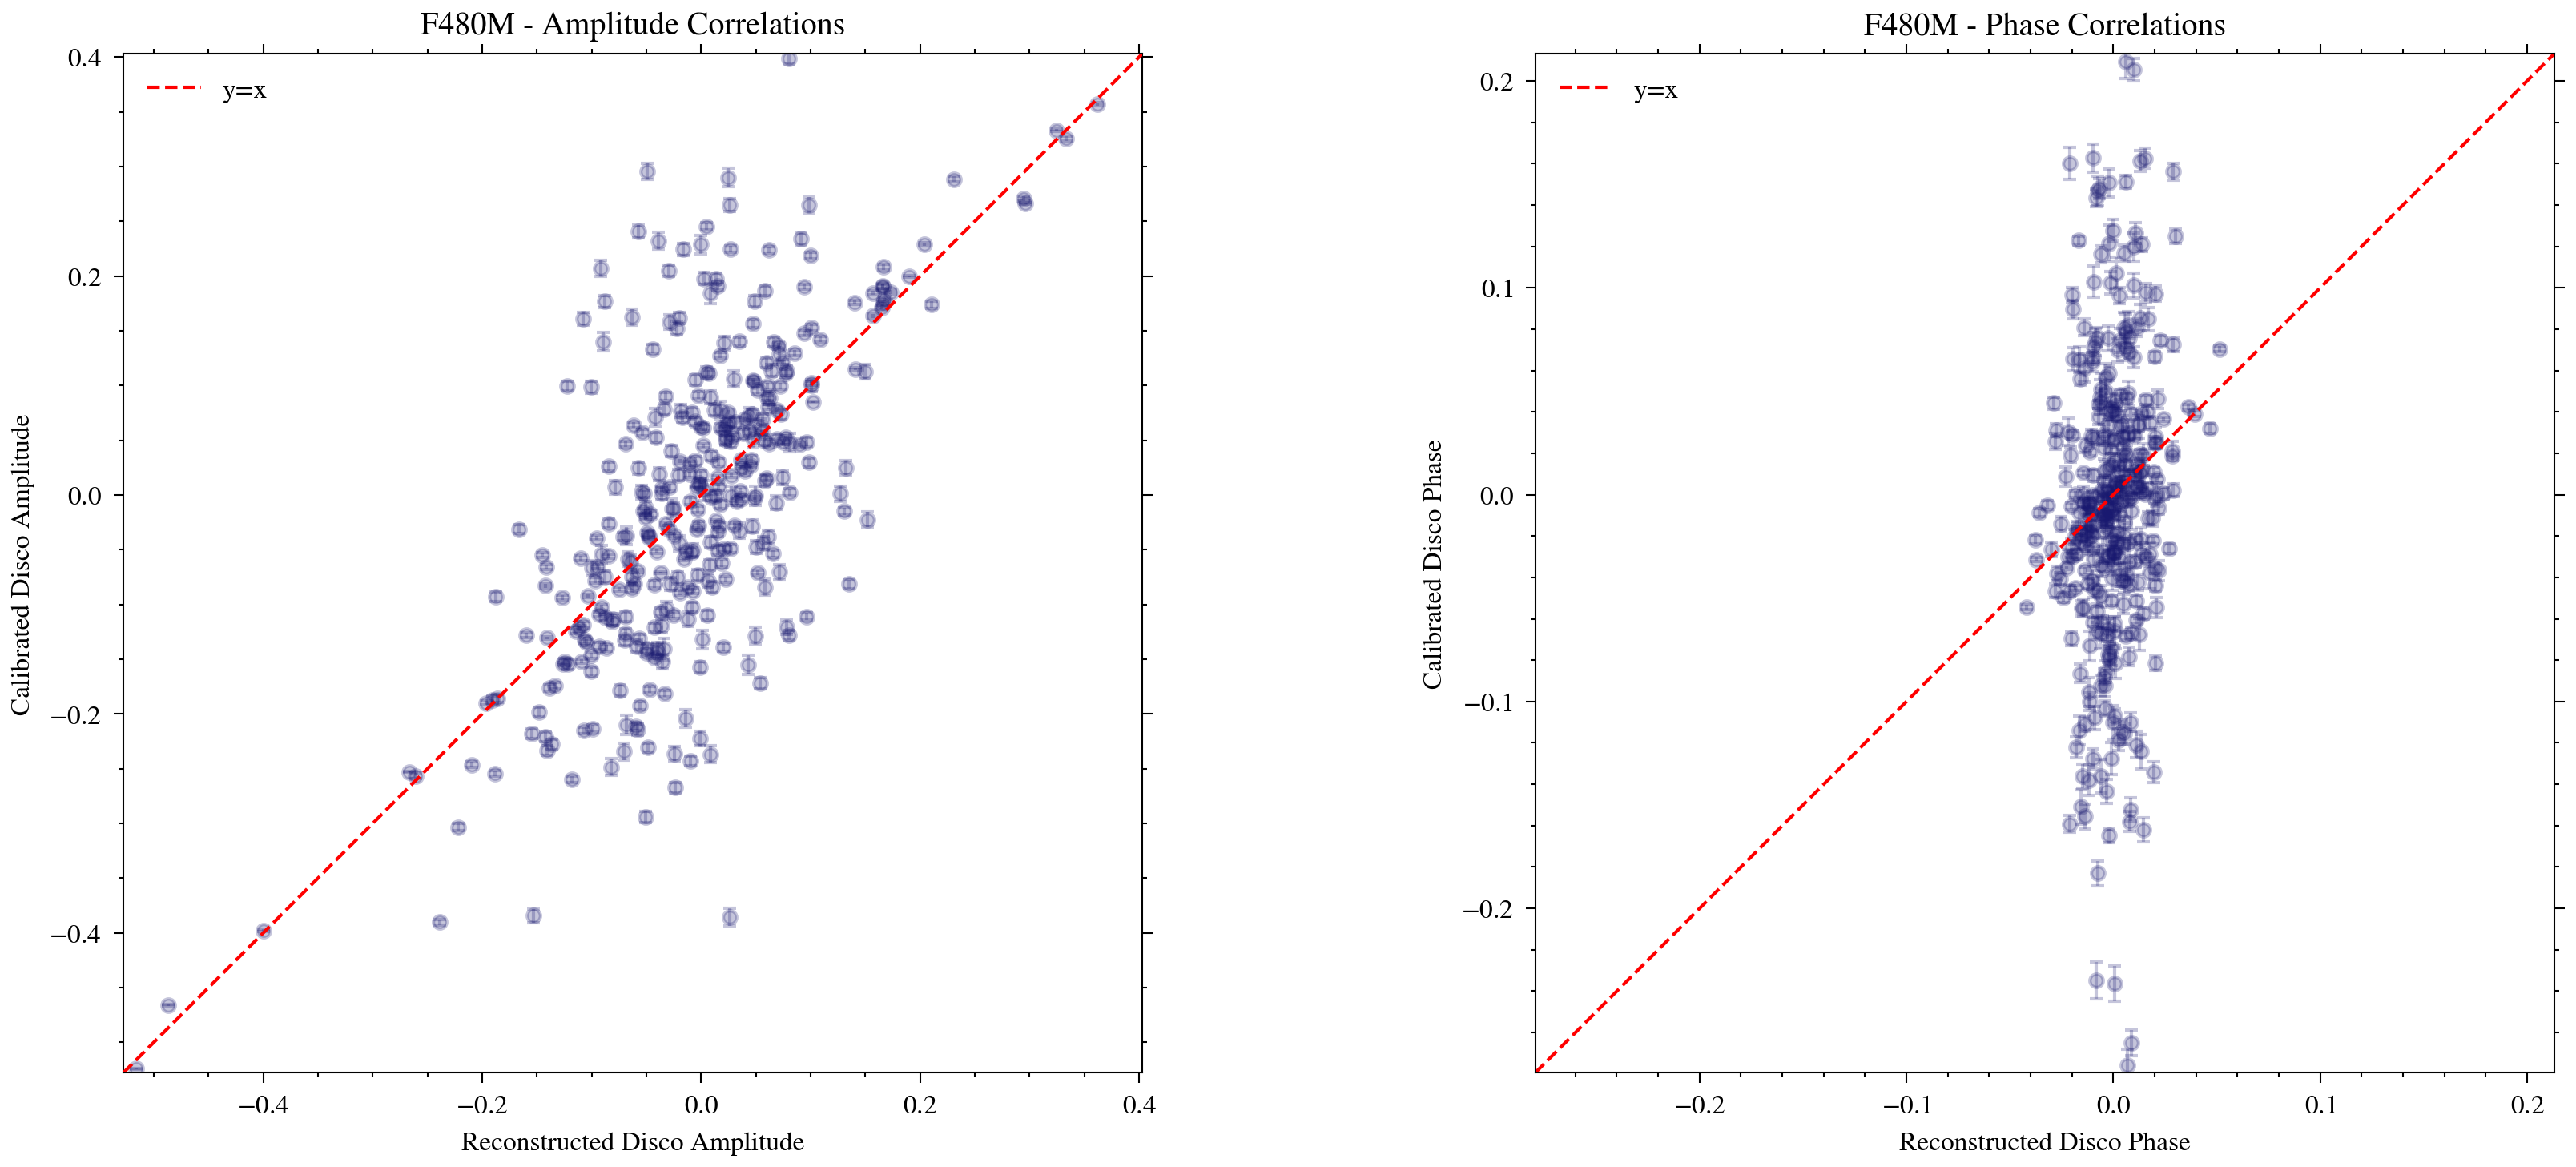

(<Figure size 3600x1500 with 2 Axes>,
 array([<Axes: title={'center': 'F480M - Amplitude Correlations'}, xlabel='Reconstructed Disco Amplitude', ylabel='Calibrated Disco Amplitude'>,
        <Axes: title={'center': 'F480M - Phase Correlations'}, xlabel='Reconstructed Disco Phase', ylabel='Calibrated Disco Phase'>],
       dtype=object))

In [20]:
disco_correlation_plot(ois, bfgs_model,'F480M')

# LAPLACE 

In [21]:
def laplace_approximation(model, oi, filter_name, args, x_opt=None):
    """Build the Laplace approximation at the BFGS optimum for one filter.

    Returns the MAP point, Hessian at MAP, and posterior covariance.
    """
    # Use the model's current params as the MAP if not provided explicitly
    if x_opt is None:
        x_opt = {
            "log_dist": model.params["log_dist"][filter_name],
            "contrast": model.params["contrast"][filter_name],
        }

    # Per-filter neg log posterior (same as in run_filter_bfgs)
    def neg_log_post(x):
        new_log_dist = dict(model.params["log_dist"])
        new_log_dist[filter_name] = x["log_dist"]
        new_contrast = dict(model.params["contrast"])
        new_contrast[filter_name] = x["contrast"]
        new_params = dict(model.params)
        new_params["log_dist"] = new_log_dist
        new_params["contrast"] = new_contrast
        m = eqx.tree_at(lambda mm: mm.params, model, new_params)
        loss, _ = disco_regularised_loss_fn(m, oi, args)
        return loss

    # Diagnostics at the MAP
    f_map = float(neg_log_post(x_opt))
    g = jax.grad(neg_log_post)(x_opt)
    g_flat, _ = ravel_pytree(g)
    print(
        f"[{filter_name}] MAP loss={f_map:.3e}, "
        f"‖grad‖_inf={float(np.max(np.abs(g_flat))):.3e}"
    )

    # Hessian at MAP
    print(f"[{filter_name}] computing Hessian at MAP...")
    H, _ = hessian(neg_log_post, x_opt, nbatches=1, jit=True)
    H_sym = 0.5 * (H + H.T)

    # Diagnose the spectrum
    eigvals = np.linalg.eigvalsh(H_sym)
    n_pos = int(np.sum(eigvals > 0))
    print(
        f"[{filter_name}] H spectrum: {n_pos}/{len(eigvals)} positive, "
        f"min={float(eigvals.min()):.2e}, max={float(eigvals.max()):.2e}"
    )

    # Posterior covariance = H^{-1}
    # Floor tiny / negative eigenvalues to keep it PSD before inversion.
    floor_rel = 1e-8
    eigvals_clipped = np.clip(eigvals, floor_rel * np.max(eigvals), None)
    eigvecs = np.linalg.eigh(H_sym)[1]
    cov = (eigvecs * (1.0 / eigvals_clipped)) @ eigvecs.T
    cov = 0.5 * (cov + cov.T)  # re-symmetrise after flooring

    # Per-parameter standard deviations
    X0, unravel = ravel_pytree(x_opt)
    sigma_flat = np.sqrt(np.diag(cov))
    sigma = unravel(sigma_flat)  # back to {"log_dist": ..., "contrast": ...}

    return {
        "x_map": x_opt,
        "H": H,
        "cov": cov,
        "sigma": sigma,  # per-parameter ±1σ
        "X0": X0,  # MAP in flat coords
        "unravel": unravel,
        "loss_map": f_map,
        "grad_inf_map": float(np.max(np.abs(g_flat))),
    }


# Run for each filter
laplace_results = {}
for oi in ois:
    fname = oi.filter
    bfgs_model = bfgs_results[fname][
        "model"
    ]  # filter-specific BFGS-updated model
    laplace_results[fname] = laplace_approximation(bfgs_model, oi, fname, args)

[F480M] MAP loss=1.420e+05, ‖grad‖_inf=3.188e+01
[F480M] computing Hessian at MAP...
[F480M] H spectrum: 170/171 positive, min=-1.12e+01, max=8.86e+07


In [22]:
laplace_key, master_key = jr.split(master_key, 2)
n_draws = 1000
X0 = laplace_results[filter]["X0"]
cov = laplace_results[filter]["cov"]
# Use eigendecomp of cov for stable sqrt
v, U = np.linalg.eigh(cov)
v_clip = np.clip(v, 0, None)
L = U * np.sqrt(v_clip)  # cov = L L^T
draws = X0[:, None] + L @ jr.normal(laplace_key, (X0.size, n_draws))
draws = draws.T  # (n_draws, n)

# Unflatten each draw
unravel = laplace_results[filter]["unravel"]
draws_pytree = jax.vmap(unravel)(draws)

In [23]:
decoded_draws = jax.vmap(decoder)(draws_pytree["log_dist"])[:,0,:,:]
decoded_draws_mean = np.median(decoded_draws, axis=0)
decoded_draws_std = np.std(decoded_draws, axis=0)

In [24]:
np.mean(ois[0].d_phi)

Array(0.00398523, dtype=float64)

In [31]:
import numpy as onp
from astropy.io import fits 

ALMA RMS = 1.602e-04 Jy/beam
Peak SNR = 83


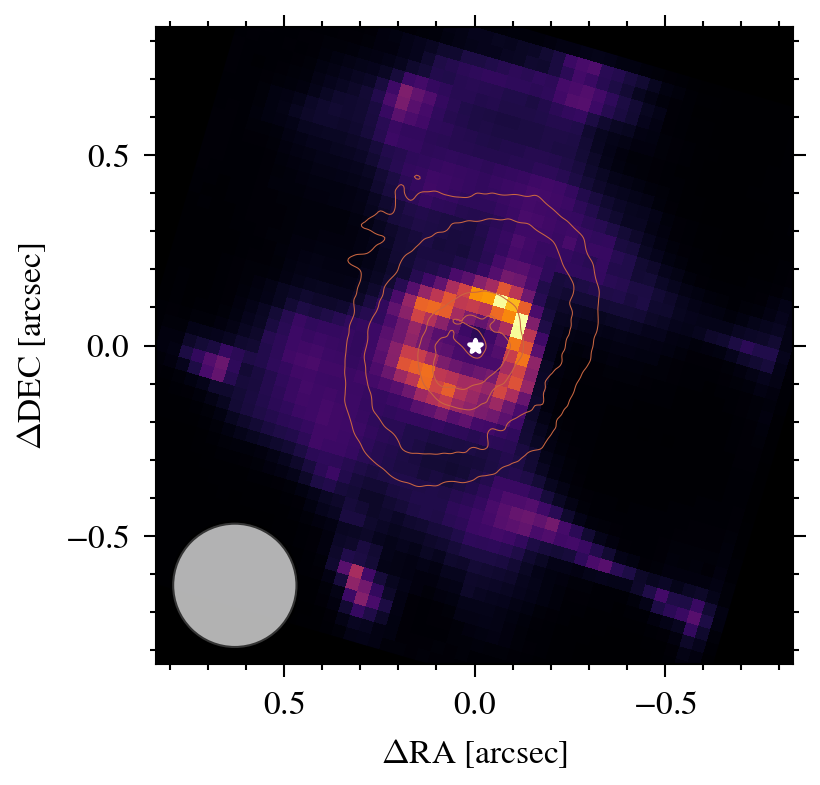

In [43]:
fig, ax = plt.subplots(figsize=(8.27/3, 8.27/3))
c0 = drt.plotting.plot_result(
    ax,
    decoded_draws_mean,
    pixel_scale=dlu.rad2arcsec(frito_model.pscale_in),
    roll_angle_degrees=-ois[0].parang,
    diff_lim=dlu.rad2arcsec(ois[0].wavel / optics_diameter),
    norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=np.max(decoded_draws_mean)),
    scale=1.0,
    cmap='inferno'
)
ax.scatter([0], [0], marker="*", color="white", s=10)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

with fits.open("_data/alma/HD100546/member.uid___A001_X2de_X155.Xa70_hd_100546_avgch_a1.clean.image.pbcor.fits") as hdul:
    alma = hdul[0].data.squeeze()
    alma_hdr = hdul[0].header

alma_pixscale = abs(alma_hdr["CDELT1"]) * 3600.0   # true 0.013"/pix
scale = 0.75

ny, nx = alma.shape
x_half = (nx / 2) * (alma_pixscale / scale)
y_half = (ny / 2) * (alma_pixscale / scale)
alma_extent = [x_half, -x_half, -y_half, y_half]   # east-left

peak = onp.nanmax(alma)
levels = onp.array([0.2, 0.5]) * peak

ny_a, nx_a = alma.shape
yy, xx = onp.ogrid[:ny_a, :nx_a]
cy, cx = ny_a // 2, nx_a // 2
r_arcsec = onp.sqrt((yy - cy)**2 + (xx - cx)**2) * alma_pixscale

# Annulus 3"–6" — well outside PDS 70's ~0.7" disk
noise_mask = (r_arcsec > 3.0) & (r_arcsec < 6.0)

rms = onp.sqrt(onp.nanmean(alma[noise_mask]**2))
# rms = onp.sqrt(onp.nanmean(alma**2))

print(f"ALMA RMS = {rms:.3e} Jy/beam")
print(f"Peak SNR = {onp.nanmax(alma) / rms:.0f}")

# Contour levels in multiples of RMS
n_rms = onp.array([10, 20, 50])
# levels = n_rms * rms

cs = ax.contour(alma, levels=levels, colors='#ca6641',
                linewidths=0.25, extent=alma_extent)

# Apply the same affine transform plot_result uses
# roll = -PDS70_ois[0].parang
# rotation_transform = (
#     mpl.transforms.Affine2D()
#     .rotate_deg(roll)
#     .scale(scale)
# )
# trans = rotation_transform + ax.transData
trans = mpl.transforms.Affine2D().scale(scale) + ax.transData

# matplotlib 3.8+ removed cs.collections; handle both
try:
    for coll in cs.collections:
        coll.set_transform(trans)
except AttributeError:
    cs.set_transform(trans)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
# ax.set_title('Laplace Posterior of HD 100546')
fig.savefig("_plots/Laplace_HD100546_480.pdf", dpi=300, bbox_inches='tight')

plt.show()

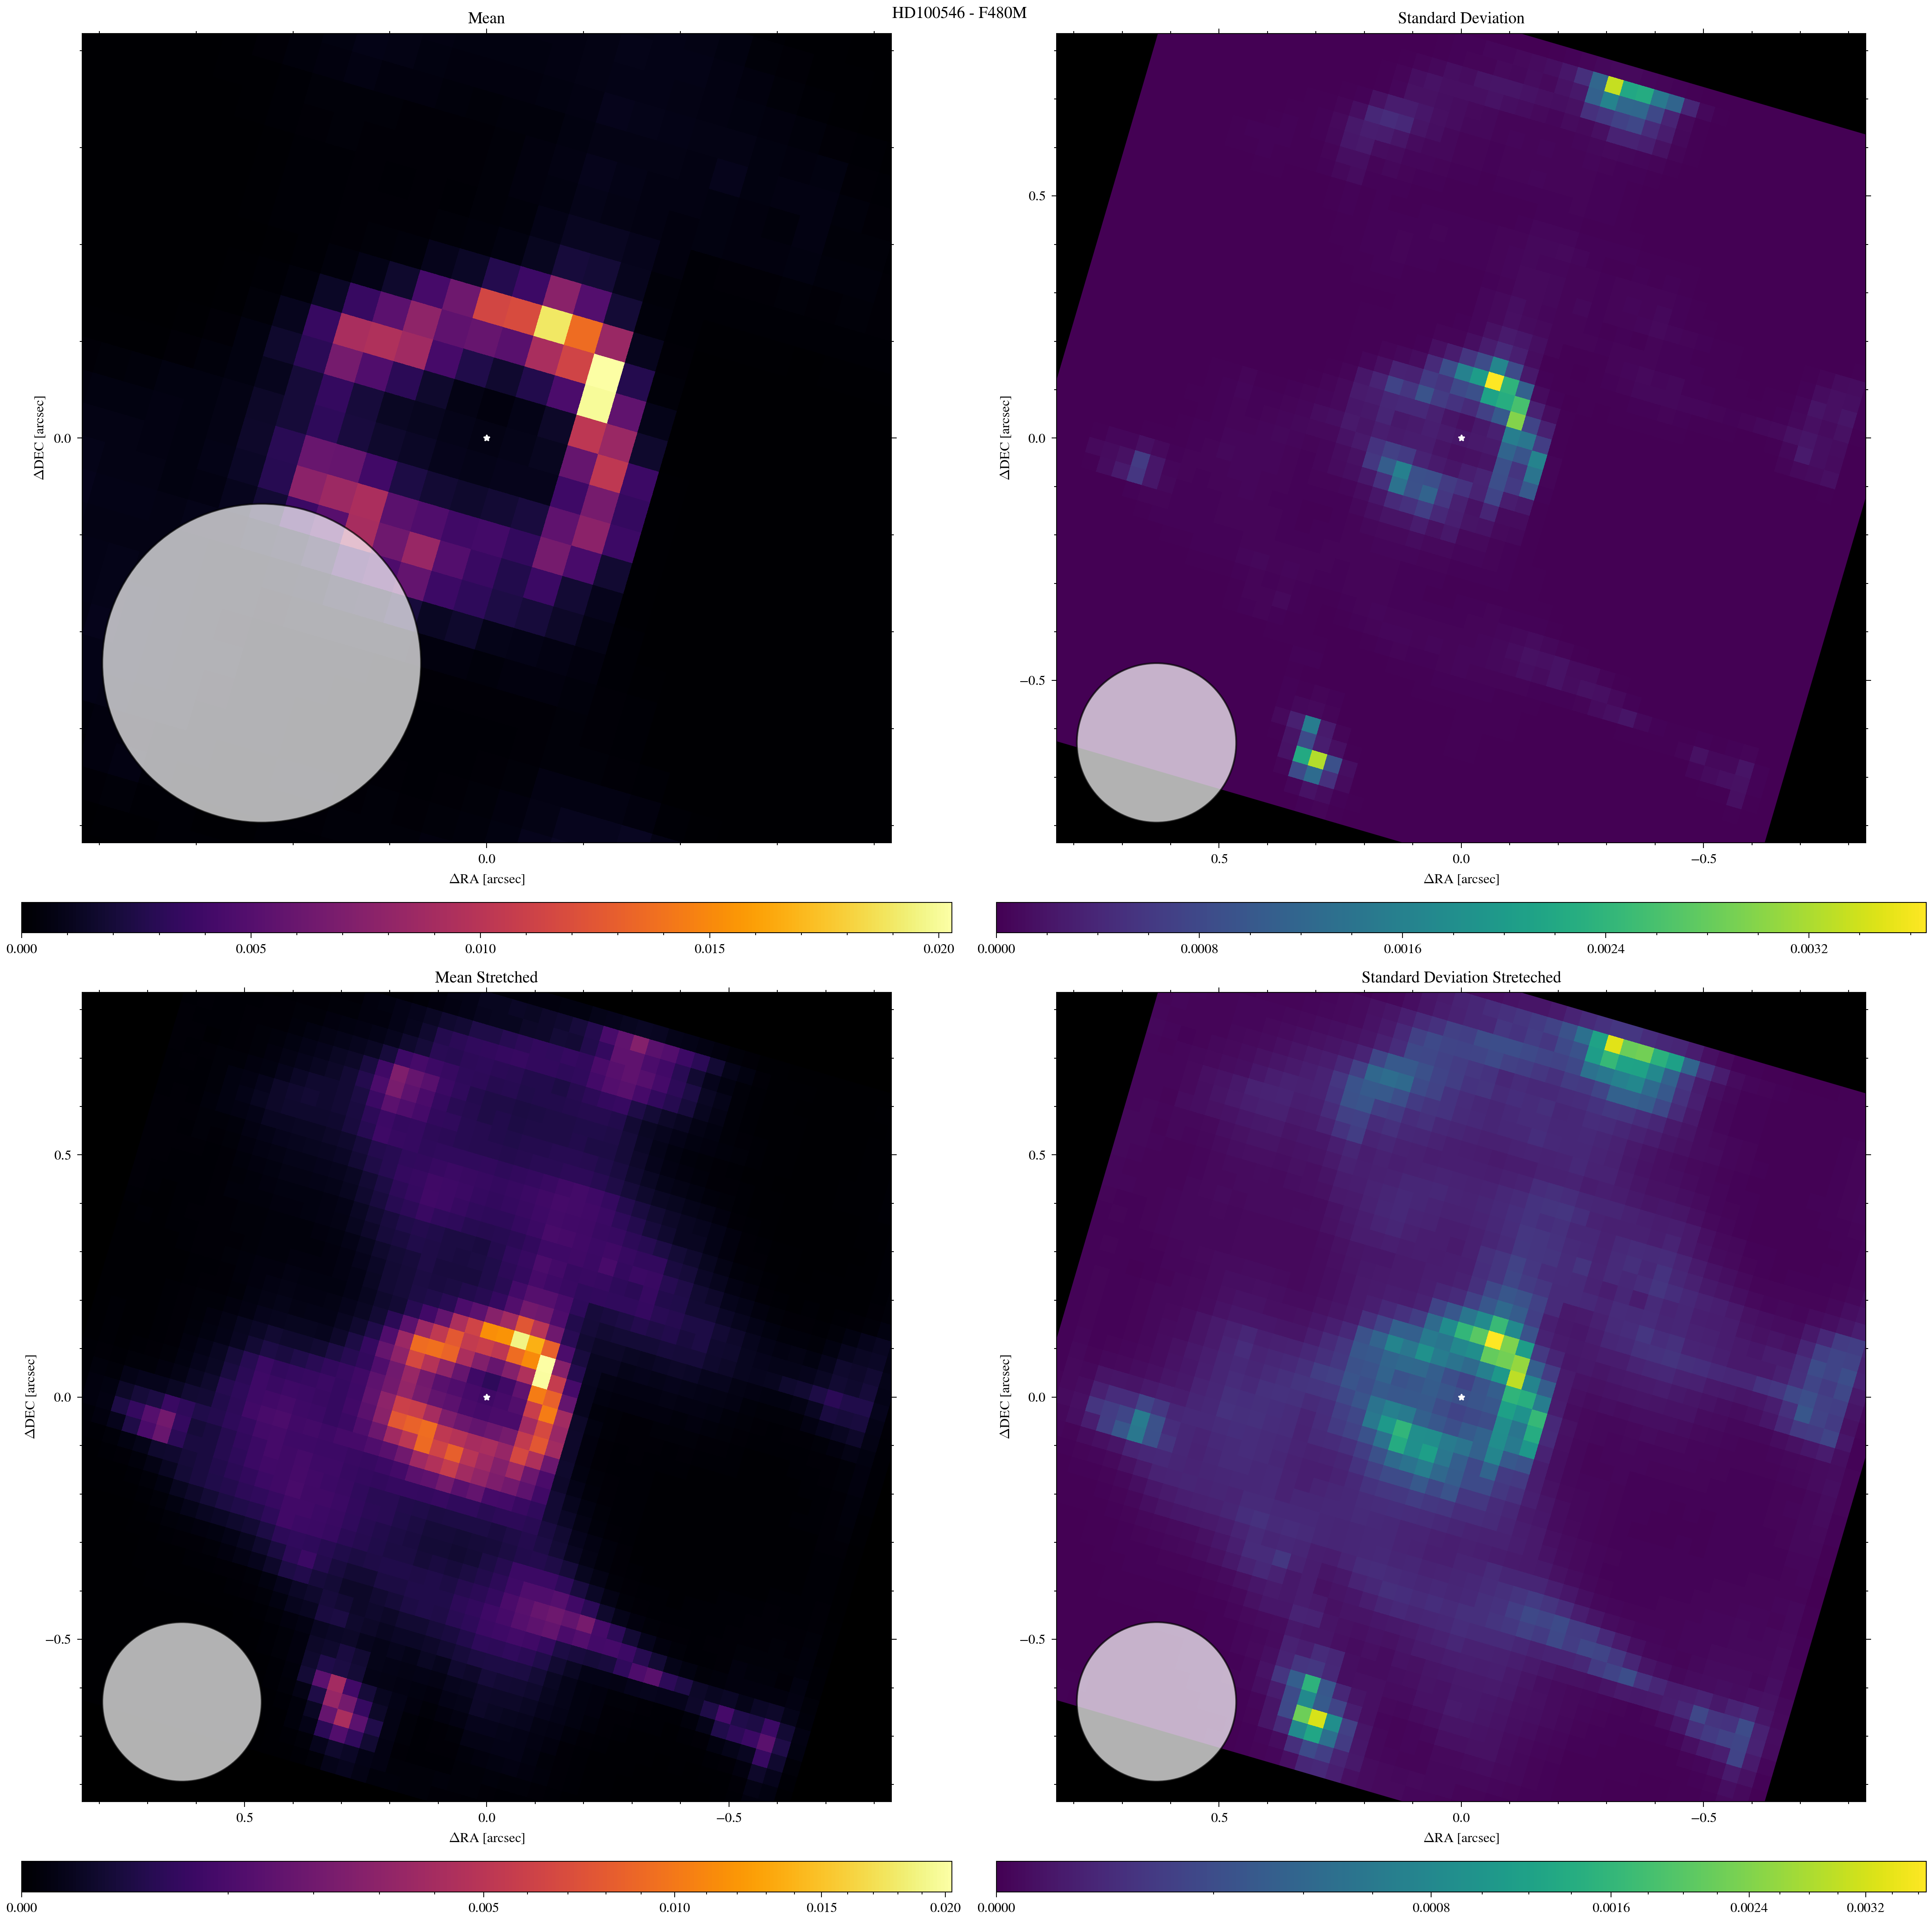

In [185]:
fig, ax_dict = plt.subplot_mosaic(
    [
        ["mean", "std"],
        ['mean_cbar', "std_cbar"],
        ['mean_stretched','std_stretched'],
        ['mean_s_cbar','std_s_cbar']
    ],
    figsize=(16,16),
    height_ratios=[4,.15,4,.15]
)
common = dict(
        pixel_scale=dlu.rad2arcsec(frito_model.pscale_in),
        roll_angle_degrees=-ois[0].parang,
        diff_lim=dlu.rad2arcsec(ois[0].wavel / optics_diameter),
    )
c0 = drt.plotting.plot_result(
    ax_dict['mean'],
    decoded_draws_mean,
    cmap="inferno",
    norm=mpl.colors.PowerNorm(1.0, vmin=0, vmax=np.max(decoded_draws_mean)),
    scale=2.0,
    **common
)

ax_dict['mean'].scatter([0],[0], marker="*", s=10, color='white')
ax_dict['mean'].set(title='Mean')

fig.colorbar(
        c0,
        cax=ax_dict['mean_cbar'],
        orientation="horizontal",
        ticks=mpl.ticker.MaxNLocator(nbins=5),
    )



c1 = drt.plotting.plot_result(
    ax_dict['std'],
    decoded_draws_std,
    cmap="viridis",
    norm=mpl.colors.PowerNorm(1.0, vmin=0, vmax=np.max(decoded_draws_std)),
    scale=1,
    **common
)
ax_dict['std'].scatter([0],[0], marker="*", s=10, color='white')
ax_dict['std'].set(title='Standard Deviation')

fig.colorbar(
        c1,
        cax=ax_dict['std_cbar'],
        orientation="horizontal",
        ticks=mpl.ticker.MaxNLocator(nbins=5),
    )

c2 = drt.plotting.plot_result(
    ax_dict['mean_stretched'],
    decoded_draws_mean,
    cmap="inferno",
    norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=np.max(decoded_draws_mean)),
    scale=1,
    **common
)

ax_dict['mean_stretched'].scatter([0],[0], marker="*", s=10, color='white')
ax_dict['mean_stretched'].set(title='Mean Stretched')

fig.colorbar(
        c2,
        cax=ax_dict['mean_s_cbar'],
        orientation="horizontal",
        ticks=mpl.ticker.MaxNLocator(nbins=5),
    )

c3 = drt.plotting.plot_result(
    ax_dict['std_stretched'],
    decoded_draws_std,
    cmap="viridis",
    norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=np.max(decoded_draws_std)),
    scale=1,
    **common
)

ax_dict['std_stretched'].scatter([0],[0], marker="*", s=10, color='white')
ax_dict['std_stretched'].set(title='Standard Deviation Streteched')

fig.colorbar(
        c3,
        cax=ax_dict['std_s_cbar'],
        orientation="horizontal",
        ticks=mpl.ticker.MaxNLocator(nbins=5),
    )

fig.suptitle(f'HD100546 - {filter}')
fig.tight_layout()

In [49]:
unravel = laplace_results[filter]["unravel"]
X0 = laplace_results[filter]["X0"]            # (171,) flat MAP
cov = laplace_results[filter]["cov"]          # (171, 171)

# Find which flat indices correspond to log_dist.
# ravel_pytree on {"log_dist": (170,), "contrast": ()} → contrast first then log_dist.
# Verify with:
test = unravel(np.arange(171, dtype=float))
print("contrast index =", float(test["contrast"]))             # 0.0
print("log_dist[0] =", float(test["log_dist"][0]))             # 1.0
print("log_dist[-1] =", float(test["log_dist"][-1]))           # 170.0

ld_idx = np.arange(1, 171)                          # log_dist indices in flat layout

X0_ld = X0[ld_idx]                                  # (170,)
cov_ld = cov[np.ix_(ld_idx, ld_idx)]                # (170, 170)

# Sample
v, U = np.linalg.eigh(cov_ld)
v_clip = np.clip(v, 0, None)
L = U * np.sqrt(v_clip)                             # cov_ld = L L^T

n_draws = 1000
draws_ld = X0_ld[:, None] + L @ jr.normal(laplace_key, (170, n_draws))
draws_ld = draws_ld.T                               # (n_draws, 170)

contrast index = 0.0
log_dist[0] = 1.0
log_dist[-1] = 170.0


In [50]:
decoded_draws = jax.vmap(decoder)(draws_ld)[:,0,:,:]
decoded_draws_mean = np.mean(decoded_draws, axis=0)
decoded_draws_std = np.std(decoded_draws, axis=0)

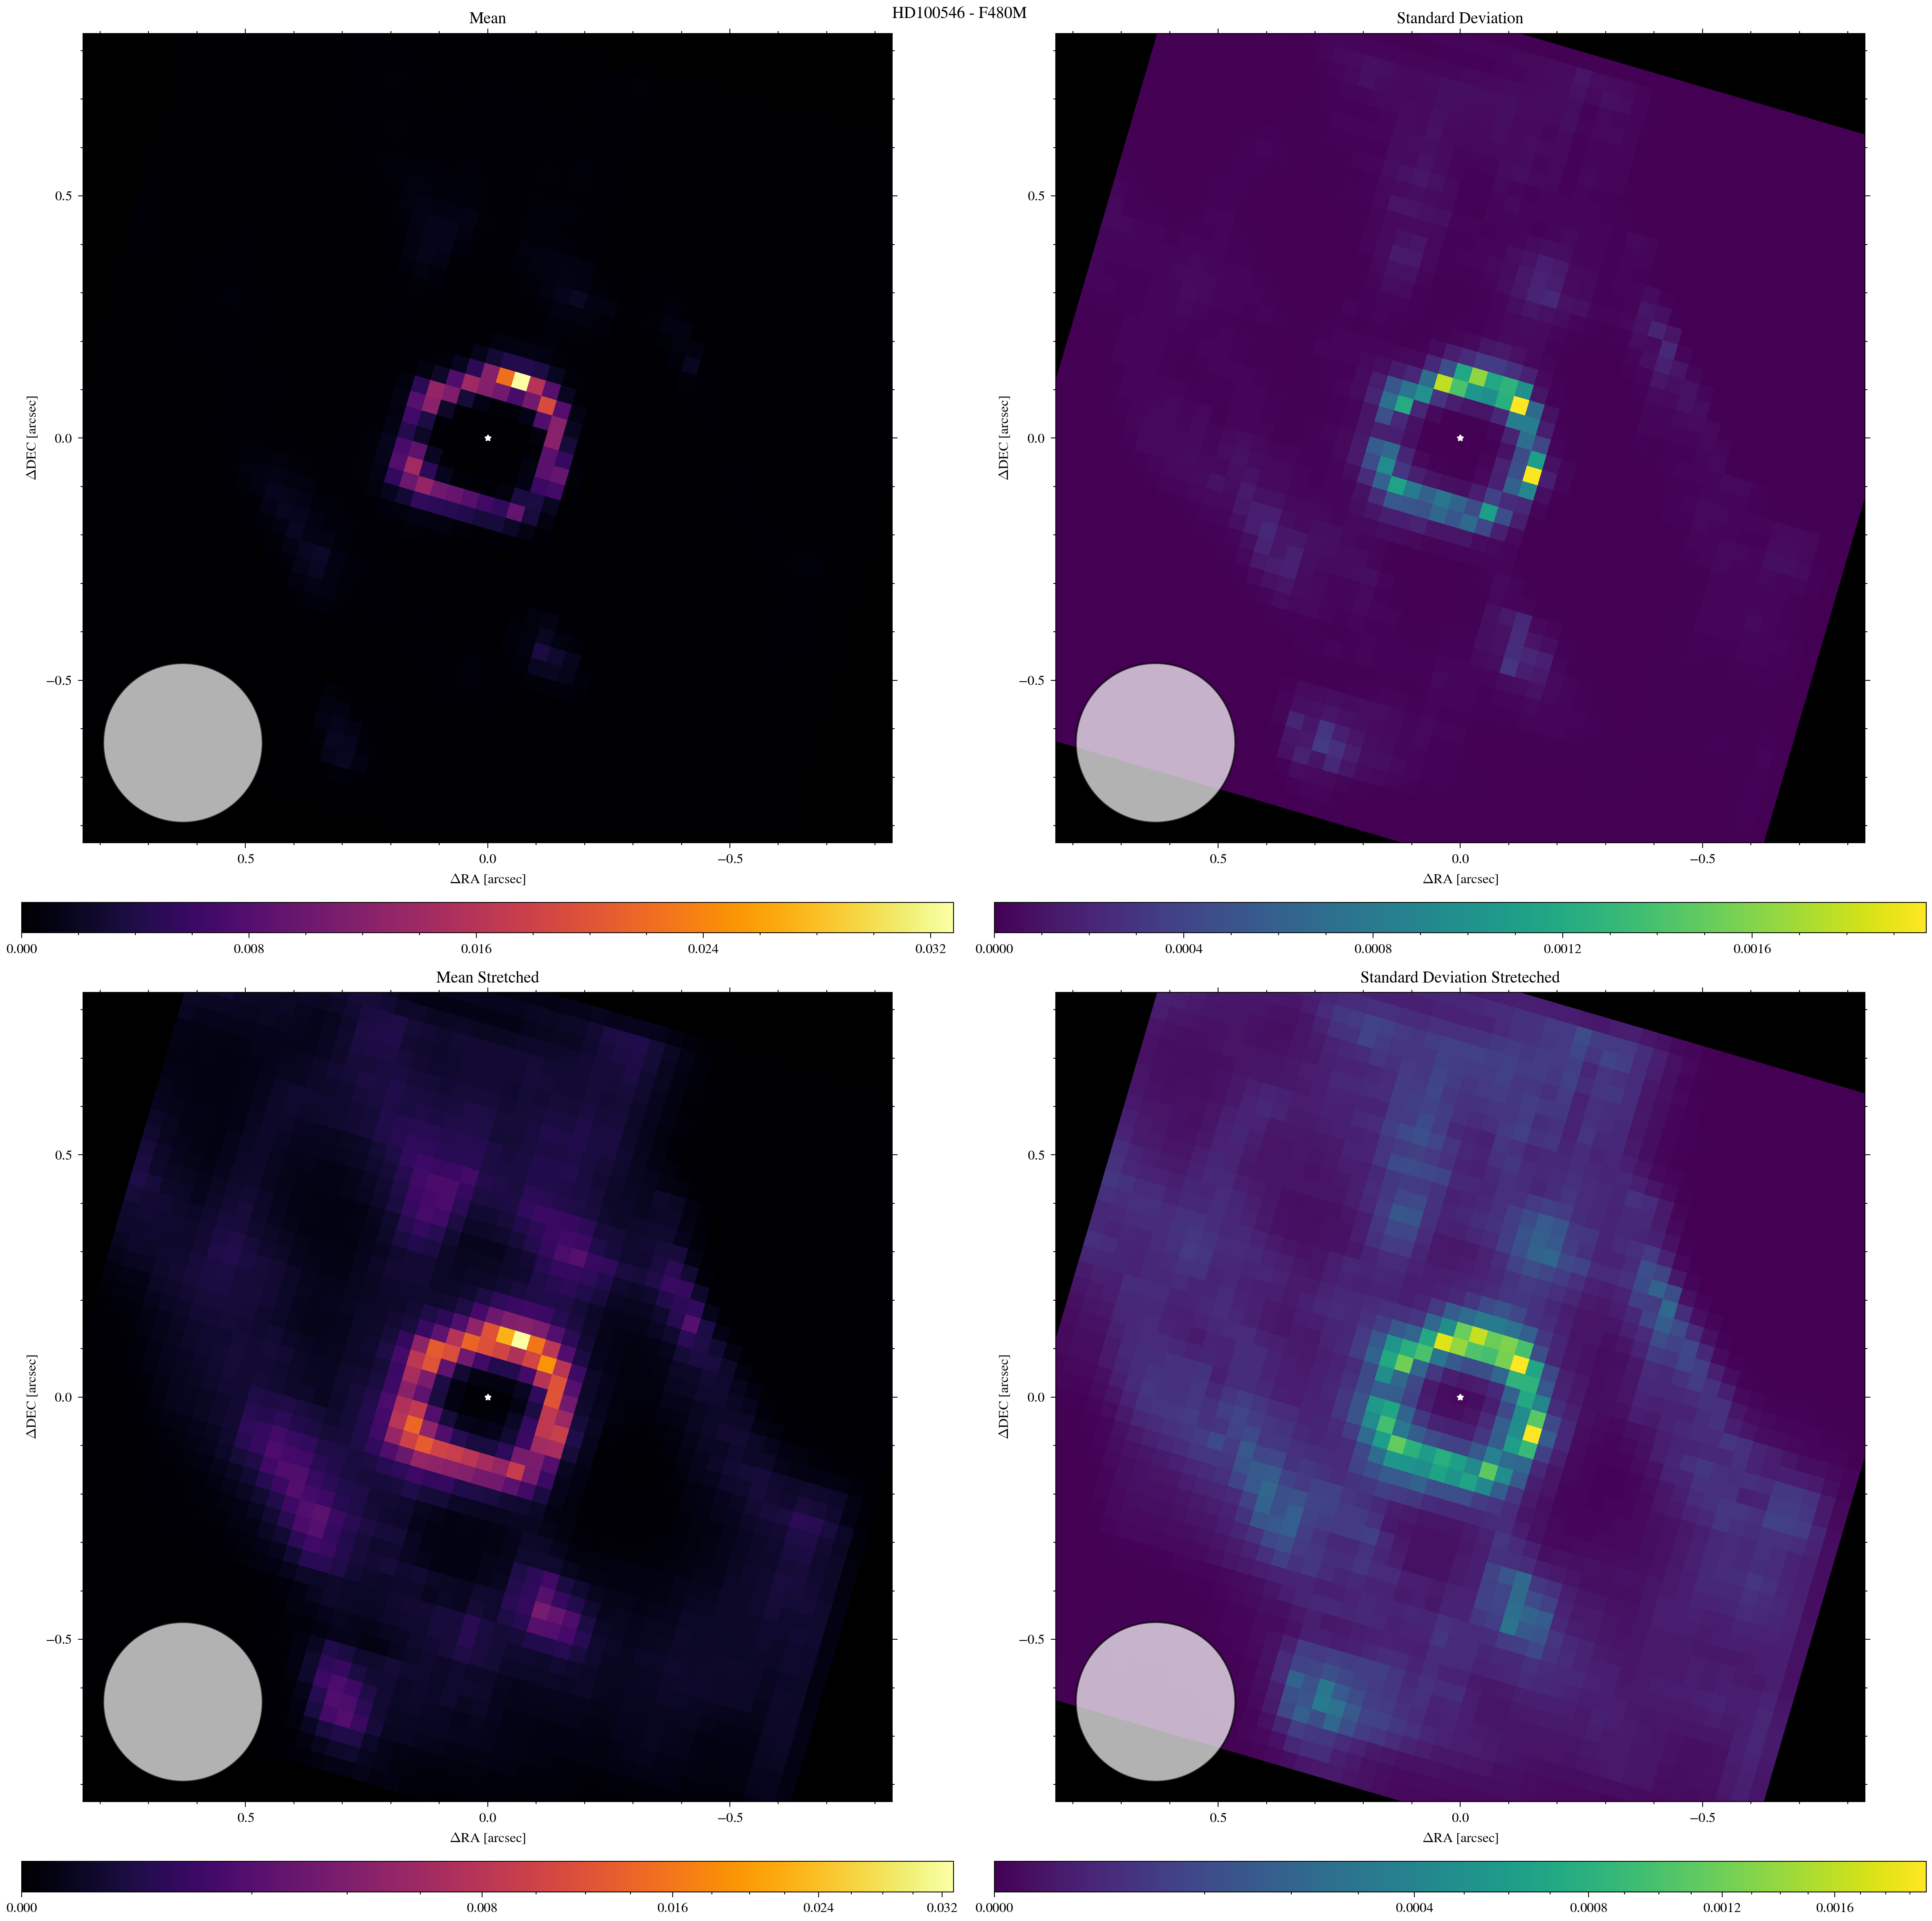

In [51]:
fig, ax_dict = plt.subplot_mosaic(
    [
        ["mean", "std"],
        ['mean_cbar', "std_cbar"],
        ['mean_stretched','std_stretched'],
        ['mean_s_cbar','std_s_cbar']
    ],
    figsize=(16,16),
    height_ratios=[4,.15,4,.15]
)
common = dict(
        pixel_scale=dlu.rad2arcsec(frito_model.pscale_in),
        roll_angle_degrees=-ois[0].parang,
        diff_lim=dlu.rad2arcsec(ois[0].wavel / optics_diameter),
    )
c0 = drt.plotting.plot_result(
    ax_dict['mean'],
    decoded_draws_mean,
    cmap="inferno",
    norm=mpl.colors.PowerNorm(1.0, vmin=0, vmax=np.max(decoded_draws_mean)),
    scale=1,
    **common
)

ax_dict['mean'].scatter([0],[0], marker="*", s=10, color='white')
ax_dict['mean'].set(title='Mean')

fig.colorbar(
        c0,
        cax=ax_dict['mean_cbar'],
        orientation="horizontal",
        ticks=mpl.ticker.MaxNLocator(nbins=5),
    )



c1 = drt.plotting.plot_result(
    ax_dict['std'],
    decoded_draws_std,
    cmap="viridis",
    norm=mpl.colors.PowerNorm(1.0, vmin=0, vmax=np.max(decoded_draws_std)),
    scale=1,
    **common
)
ax_dict['std'].scatter([0],[0], marker="*", s=10, color='white')
ax_dict['std'].set(title='Standard Deviation')

fig.colorbar(
        c1,
        cax=ax_dict['std_cbar'],
        orientation="horizontal",
        ticks=mpl.ticker.MaxNLocator(nbins=5),
    )

c2 = drt.plotting.plot_result(
    ax_dict['mean_stretched'],
    decoded_draws_mean,
    cmap="inferno",
    norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=np.max(decoded_draws_mean)),
    scale=1,
    **common
)

ax_dict['mean_stretched'].scatter([0],[0], marker="*", s=10, color='white')
ax_dict['mean_stretched'].set(title='Mean Stretched')

fig.colorbar(
        c2,
        cax=ax_dict['mean_s_cbar'],
        orientation="horizontal",
        ticks=mpl.ticker.MaxNLocator(nbins=5),
    )

c3 = drt.plotting.plot_result(
    ax_dict['std_stretched'],
    decoded_draws_std,
    cmap="viridis",
    norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=np.max(decoded_draws_std)),
    scale=1,
    **common
)

ax_dict['std_stretched'].scatter([0],[0], marker="*", s=10, color='white')
ax_dict['std_stretched'].set(title='Standard Deviation Streteched')

fig.colorbar(
        c3,
        cax=ax_dict['std_s_cbar'],
        orientation="horizontal",
        ticks=mpl.ticker.MaxNLocator(nbins=5),
    )

fig.suptitle(f'HD100546 - {filter}')
fig.tight_layout()

In [52]:
disco_PDS70['F380M'].keys()

dict_keys(['u', 'v', 'vis_mat', 'phi_mat', 'K_vis_mat', 'K_phi_mat', 'parang', 'wavel', 'O_vis', 'O_phi', 'O_vis_cov', 'O_phi_cov', 'O_vis_mat', 'O_phi_mat', 'O_vis_eigv', 'O_phi_eigv', 'disco_vis_mat', 'disco_phi_mat', 'K_vis', 'K_vis_cov', 'K_phi', 'K_phi_cov', 'vis', 'vis_cov', 'phi', 'phi_cov'])

In [23]:
disco_PDS70['F380M']['vis'].shape

(420,)

In [24]:
baselines = np.sqrt(disco_PDS70['F380M']['u']**2 + disco_PDS70['F380M']['v']**2)

In [25]:
baselines

Array([9.155597  , 8.974353  , 8.796999  , ..., 0.7768781 , 0.51791877,
       0.25895938], dtype=float32)

In [26]:
disco_PDS70['F380M']['vis'].shape

(420,)

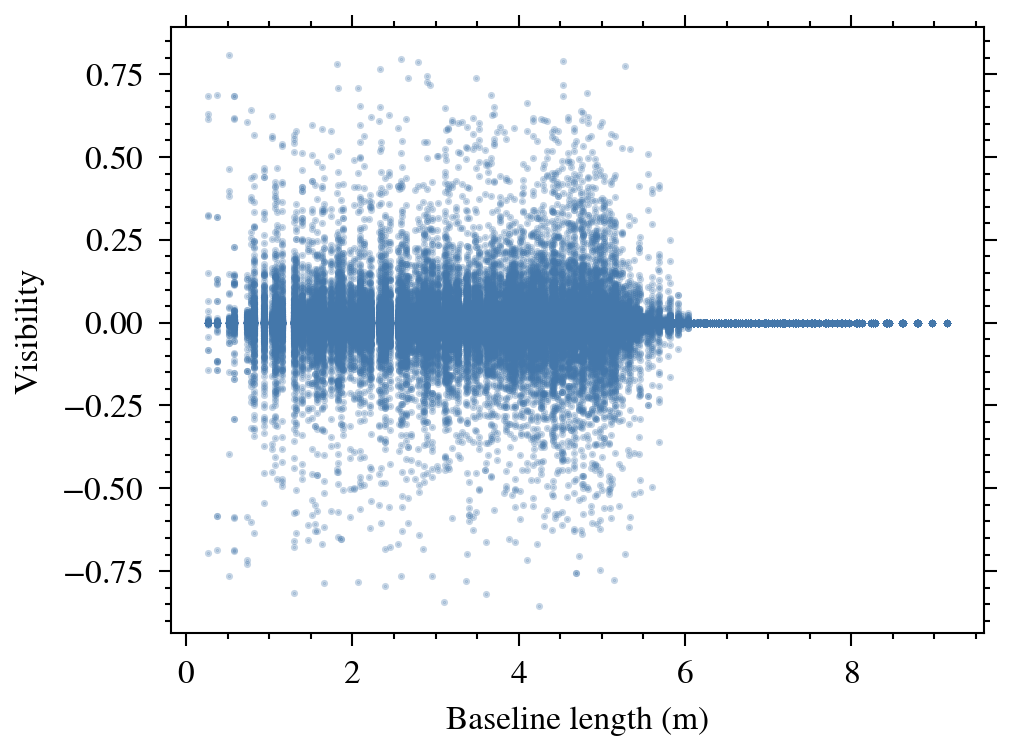

In [27]:
# Baseline per wavelength channel
baselines = np.sqrt(disco_PDS70['F380M']['u']**2 + disco_PDS70['F380M']['v']**2)  # (1300,)

# Flatten vis_mat and baselines to plot everything together
vis_flat = disco_PDS70['F380M']['vis_mat'].flatten()        # (420*1300,)
base_flat = np.tile(baselines, 420)         # (420*1300,)

plt.scatter(base_flat, vis_flat, s=0.5, alpha=0.3)
plt.xlabel('Baseline length (m)')
plt.ylabel('Visibility')
plt.show()

In [28]:
disco_PDS70['F380M']['wavel']

Array(3.823038e-06, dtype=float32)

In [29]:
# Find where visibilities effectively drop to zero
threshold = 0.005  # or some small value above noise

# Max baseline where vis is still non-zero
B_null = base_flat[vis_flat > threshold].max()

theta = disco_PDS70['F380M']['wavel'] / B_null  # radians
theta_mas = np.degrees(theta) * 3600 * 1000

In [30]:
B_null

Array(6.039919, dtype=float32)

In [31]:
ois[0].vis_mat.shape

(349, 1300)

In [32]:
baselines = np.sqrt(ois[0].u**2+ois[0].v**2)
base_flat = np.tile(baselines, ois[0].vis_mat.shape[0])
threshold = 0.005
B_null = base_flat[ois[0].vis_mat.flatten() > threshold].max()
